# **Predicting Breast Cancer Diagnosis Using a Multi-Layer Perceptron (MLP) in PyTorch**


1. Problem Statement

2. Data Preparation

3. Initial Neural Network Experiment
   - 500 Epochs
   - Analysis
   - Overfitting Detection

4. Improved Neural Network
   - 100 Epochs
   - Weight Decay
   - Results

5. Loss Curve Visualization

6. Final Conclusions



# Predicting Breast Cancer Diagnosis Using a Multi-Layer Perceptron (MLP) in PyTorch

## Project Overview

This project explores the use of a Multi-Layer Perceptron (MLP) neural network to classify breast cancer diagnoses as malignant or benign using the Breast Cancer Wisconsin Dataset.

The objective was not only to build an accurate model but also to understand:

- How neural networks learn
- How overfitting occurs
- How regularization improves generalization
- How to evaluate model performance using training and validation metrics

The project compares two experiments:

1. An initial model that showed signs of overfitting
2. An improved model designed to generalize better

In [1]:
# =========================
# IMPORT LIBRARIES
# =========================
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import torch
from torch import nn, optim



## Dataset

The Breast Cancer Wisconsin Dataset contains diagnostic measurements used to classify tumors as malignant or benign.


In [2]:
# =========================
# LOAD DATA
# =========================
data = load_breast_cancer()
x = data.data
y = data.target


## Data Preparation

The data is split into training, validation, and test sets.

Standardization is applied to ensure all features are on a similar scale before training the neural network.


In [3]:
# =========================
# TRAIN / VALIDATION / TEST SPLIT
# =========================
x_train_val, x_test, y_train_val, y_test = train_test_split(
    x, y, test_size=0.1, random_state=42
)

x_train, x_val, y_train, y_val = train_test_split(
    x_train_val, y_train_val, test_size=0.2, random_state=42
)


# =========================
# SCALING
# =========================
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)


# =========================
# CONVERT TO PYTORCH TENSORS
# =========================
x_train = torch.tensor(x_train, dtype=torch.float32)
x_val = torch.tensor(x_val, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)




# Experiment 1: Detecting Overfitting

The first experiment uses:

- Hidden Layer 1: 50 neurons
- Hidden Layer 2: 50 neurons
- Epochs: 500
- Learning Rate: 0.001
- Weight Decay: 0

Objective:

Observe how a larger model behaves during prolonged training.


## Model Architecture

In [4]:
# =========================
# MODEL PARAMETERS
# =========================
input_size = x_train.shape[1]
hidden_1 = 50
hidden_2 = 50
output_size = 2


# =========================
# DEFINE MODEL
# =========================
class MLP(nn.Module):
    def __init__(self, input_size, hidden_1, hidden_2, output_size):
        super(MLP, self).__init__()

        self.layer1 = nn.Linear(input_size, hidden_1)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(hidden_1, hidden_2)
        self.output = nn.Linear(hidden_2, output_size)

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.output(x)
        return x

## Training the Initial Model

In [5]:
# =========================
# INITIALIZE MODEL
# =========================
model = MLP(input_size, hidden_1, hidden_2, output_size)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


# =========================
# TRAINING LOOP
# =========================
epochs = 500

train_losses = []
val_losses = []

for epoch in range(epochs):

    # ---- TRAINING ----
    model.train()
    outputs = model(x_train)
    loss_train = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss_train.backward()
    optimizer.step()

    train_losses.append(loss_train.item())

    # ---- VALIDATION ----
    model.eval()
    with torch.no_grad():
        val_outputs = model(x_val)
        loss_val = criterion(val_outputs, y_val)

        val_losses.append(loss_val.item())

        _, val_preds = torch.max(val_outputs, 1)
        val_acc = accuracy_score(y_val.numpy(), val_preds.numpy())

    # ---- PRINT PROGRESS ----
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}]")
        print("Train Loss:", loss_train.item())
        print("Val Loss:", loss_val.item())
        print("Val Accuracy:", val_acc)
        print("-" * 30)


# =========================
# FINAL TEST EVALUATION
# =========================
model.eval()
with torch.no_grad():
    test_outputs = model(x_test)
    test_loss = criterion(test_outputs, y_test)

    _, test_preds = torch.max(test_outputs, 1)
    test_acc = accuracy_score(y_test.numpy(), test_preds.numpy())

print("\nFINAL RESULTS")
print("Test Loss:", test_loss.item())
print("Test Accuracy:", test_acc)

Epoch [100/500]
Train Loss: 0.03881450742483139
Val Loss: 0.12073004245758057
Val Accuracy: 0.9611650485436893
------------------------------
Epoch [200/500]
Train Loss: 0.008595485240221024
Val Loss: 0.21084436774253845
Val Accuracy: 0.9611650485436893
------------------------------
Epoch [300/500]
Train Loss: 0.002383009996265173
Val Loss: 0.2846403121948242
Val Accuracy: 0.970873786407767
------------------------------
Epoch [400/500]
Train Loss: 0.0010113486787304282
Val Loss: 0.3359975218772888
Val Accuracy: 0.9611650485436893
------------------------------
Epoch [500/500]
Train Loss: 0.0005467235459946096
Val Loss: 0.3717576861381531
Val Accuracy: 0.9611650485436893
------------------------------

FINAL RESULTS
Test Loss: 0.18290454149246216
Test Accuracy: 0.9649122807017544



### Final Results

Training Loss: 0.0005

Validation Loss: 0.3718

Validation Accuracy: 96.12%

Test Loss: 0.1829

Test Accuracy: 96.49%



### Analysis

The model continued to improve on the training data, as shown by the decreasing training loss.

However, validation loss increased steadily after early training.

This indicates that the model was beginning to memorize the training data instead of learning general patterns.

Conclusion:

The model exhibited signs of overfitting.


# Experiment 2: Improving Generalization

To reduce overfitting, three modifications were introduced:

- Hidden Layers reduced from (50,50) to (20,20)
- Training epochs reduced from 500 to 100
- Weight decay regularization added (0.01)

The same training, validation, and test datasets were used to ensure a fair comparison.

## Improved Model Architecture

## Training the Improved Model

Epoch [10/100]
Train Loss: 0.6222401261329651
Val Loss: 0.6090868711471558
Val Accuracy: 0.6796116504854369
------------------------------
Epoch [20/100]
Train Loss: 0.5499114990234375
Val Loss: 0.5353109836578369
Val Accuracy: 0.7961165048543689
------------------------------
Epoch [30/100]
Train Loss: 0.4700087308883667
Val Loss: 0.4521891474723816
Val Accuracy: 0.8932038834951457
------------------------------
Epoch [40/100]
Train Loss: 0.3878515660762787
Val Loss: 0.36678266525268555
Val Accuracy: 0.912621359223301
------------------------------
Epoch [50/100]
Train Loss: 0.31183725595474243
Val Loss: 0.2888726592063904
Val Accuracy: 0.9320388349514563
------------------------------
Epoch [60/100]
Train Loss: 0.24616143107414246
Val Loss: 0.2247261255979538
Val Accuracy: 0.970873786407767
------------------------------
Epoch [70/100]
Train Loss: 0.19373026490211487
Val Loss: 0.1745658814907074
Val Accuracy: 0.9805825242718447
------------------------------
Epoch [80/100]
Train Loss

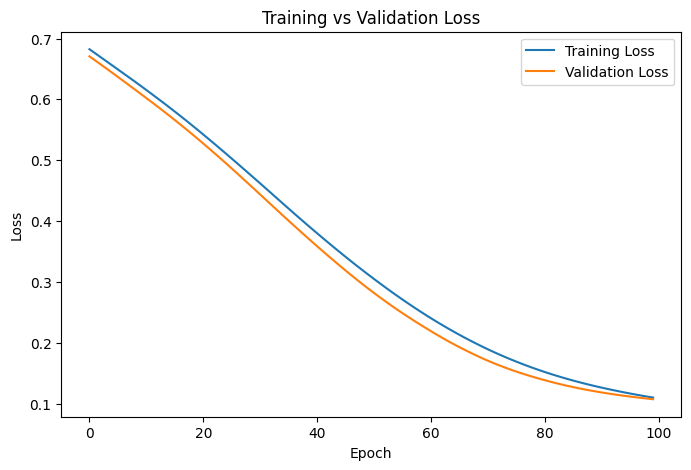


FINAL RESULTS
Test Loss: 0.10161042958498001
Test Accuracy: 0.9649122807017544


In [6]:
# =========================
# MODEL PARAMETERS
# =========================
input_size = x_train.shape[1]
hidden_1 = 20
hidden_2 = 20
output_size = 2


# =========================
# DEFINE MODEL
# =========================
class MLP(nn.Module):
    def __init__(self, input_size, hidden_1, hidden_2, output_size):
        super(MLP, self).__init__()

        self.layer1 = nn.Linear(input_size, hidden_1)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(hidden_1, hidden_2)
        self.output = nn.Linear(hidden_2, output_size)

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.output(x)
        return x


# =========================
# INITIALIZE MODEL
# =========================
model = MLP(input_size, hidden_1, hidden_2, output_size)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)


# =========================
# TRAINING LOOP
# =========================
epochs = 100

train_losses = []
val_losses = []

for epoch in range(epochs):

    # ---- TRAINING ----
    model.train()
    outputs = model(x_train)
    loss_train = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss_train.backward()
    optimizer.step()

    train_losses.append(loss_train.item())

    # ---- VALIDATION ----
    model.eval()
    with torch.no_grad():
        val_outputs = model(x_val)
        loss_val = criterion(val_outputs, y_val)

        val_losses.append(loss_val.item())

        _, val_preds = torch.max(val_outputs, 1)
        val_acc = accuracy_score(y_val.numpy(), val_preds.numpy())

    # ---- PRINT PROGRESS ----
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}]")
        print("Train Loss:", loss_train.item())
        print("Val Loss:", loss_val.item())
        print("Val Accuracy:", val_acc)
        print("-" * 30)


import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


# =========================
# FINAL TEST EVALUATION
# =========================
model.eval()
with torch.no_grad():
    test_outputs = model(x_test)
    test_loss = criterion(test_outputs, y_test)

    _, test_preds = torch.max(test_outputs, 1)
    test_acc = accuracy_score(y_test.numpy(), test_preds.numpy())

print("\nFINAL RESULTS")
print("Test Loss:", test_loss.item())
print("Test Accuracy:", test_acc)

## Experiment 2 Results


### Final Results

Training Loss: 0.1100

Validation Loss: 0.1073

Validation Accuracy: 99.03%

Test Loss: 0.1016

Test Accuracy: 96.49%


### Analysis

Training and validation losses decreased steadily throughout training.

Unlike Experiment 1, the validation loss remained closely aligned with training loss.

This suggests that the model successfully learned meaningful patterns while maintaining strong generalization performance.

The introduction of regularization and reduced model complexity improved the model's ability to generalize to unseen data.

### Analysis

Training and validation losses decreased steadily throughout training.

Unlike Experiment 1, the validation loss remained closely aligned with training loss.

This suggests that the model successfully learned meaningful patterns while maintaining strong generalization performance.

The introduction of regularization and reduced model complexity improved the model's ability to generalize to unseen data.

# Training vs Validation Loss Visualization

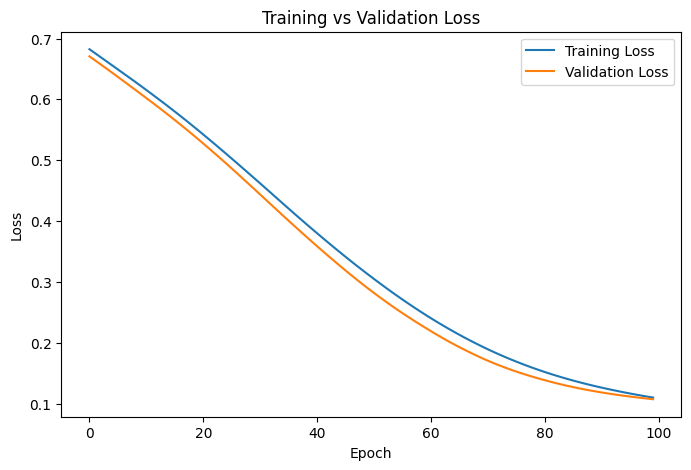

In [7]:

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

# Key Learnings

Through this project, I learned:

- How neural networks learn through forward propagation and backpropagation
- How to monitor training and validation metrics
- How to identify overfitting using loss curves
- How regularization can improve generalization
- Why lower training loss does not always imply a better model

Most importantly, I learned that model evaluation should focus on generalization rather than training performance alone.

# Reflection

This project started as an effort to build a neural network in PyTorch.

It became an opportunity to understand how models learn, why they fail, and how they can be improved.

The most valuable lesson was not achieving high accuracy.

It was learning how to identify overfitting, interpret model behavior, and make informed improvements based on evidence.

